# Lorenz-63 Model

The Lorenz-63 model is commonly used to assess various data assimilation methods for nonlinear systems. This model is of interest because of its nonlinear chaotic behavior and low dimensions. The simple three-variable model is composed of a system of nonlinear ordinary differential equations:
\begin{gather*}
	\frac{\partial x}{\partial t} &=& \sigma (y-x) \\
	\frac{\partial y}{\partial t} &=& \rho x-y-xz \\
	\frac{\partial z}{\partial t} &=& xy-\beta z
\end{gather*}
We will use the following common parameter values for the reference solution: $\sigma = 10$, $\rho = 28$, and $\beta = 8/3$. 

<!-- The reference solution will have the initial conditions of $(x_0, y_0, z_0) = (1.508870, -1.531271, 25.46091)$ and a time interval of $t \in [0, 40]$. -->

The observations are generated by adding Gaussian noise with zero mean and a variance of 2.0 to the reference solution and will be measured at regular time intervals $\Delta t = 0.1$.

In [11]:
# LIBRARIES
from main import run_data_assimilation
from models.lorenz63 import Lorenz63
import scipy.io as sio
import numpy as np
from utils.plots import plot_particles, plot_lorenz63, plot_rmses
import matplotlib.pyplot as plt
from observation_operators import linear_gaussian
from filters.kde import KernelDensityEstimation
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display
import os

data_path = "data/initial/"
T_spinup = 2000
np.random.seed(10) 

In [18]:
# Define ensemble sizes to test
ensemble_sizes = [10, 20, 40, 60, 100, 200, 400, 600]
# ensemble_sizes = [10, 100, 600]

# Set up filter parameters
sigma_config = {
    "method": "manual",
    "sigma_scale": "linear", # TODO: Move to filter_params
    "sigma_start": 0.1, 
    "sigma_end": 50, 
    "sigma_obs": 2}
filter_params = {
    'sigma_config': sigma_config,
    'obs_std': 2,
    'obs_op': linear_gaussian, # TODO: Make obs_op as a class
    'N_tsteps': 250
    }

filter = KernelDensityEstimation(**filter_params) # Initialize filter

# Dictionaries to store models
models = {}

for ensemble_size in ensemble_sizes:

    # Load data
    data = sio.loadmat(data_path + f"spinup_M{ensemble_size}.mat")['model']
    initial_ensemble = np.array(data['x0'][0][0])

    # Set up model parameters
    model_params = {
        'sigma': 10.0,
        'rho': 28.0,
        'beta': 8.0 / 3.0,
        'for_dt': 0.05, 
        'obs_dt': 0.1, 
        'T_steps': 4000, # Number of assimilation steps
        'T_burnin': 2000,
        'ensemble_size': ensemble_size,
        'process_noise': 10e-2, # std
        'rand_seed': 10,
        'initial_ensemble': initial_ensemble + np.random.normal(0, np.sqrt(2), initial_ensemble.shape),
        'initial_time': 200, # TODO: Replave with T_spinup
        'ref_initial_state': np.array(data['xt'][0][0].T)[T_spinup-1],
        'obs_noise': 2 # std
    }

    model = Lorenz63(**model_params) # Initialize model

    # Run data assimilation
    run_data_assimilation(model, filter)

    # Store model
    models[ensemble_size] = model

Data Assimilation (Ensemble Size=10):   0%|          | 0/4000 [00:00<?, ?step/s]

Data Assimilation (Ensemble Size=20):   0%|          | 0/4000 [00:00<?, ?step/s]

Data Assimilation (Ensemble Size=40):   0%|          | 0/4000 [00:00<?, ?step/s]

Data Assimilation (Ensemble Size=60):   0%|          | 0/4000 [00:00<?, ?step/s]

Data Assimilation (Ensemble Size=100):   0%|          | 0/4000 [00:00<?, ?step/s]

Data Assimilation (Ensemble Size=200):   0%|          | 0/4000 [00:00<?, ?step/s]

Data Assimilation (Ensemble Size=400):   0%|          | 0/4000 [00:00<?, ?step/s]

Data Assimilation (Ensemble Size=600):   0%|          | 0/4000 [00:00<?, ?step/s]

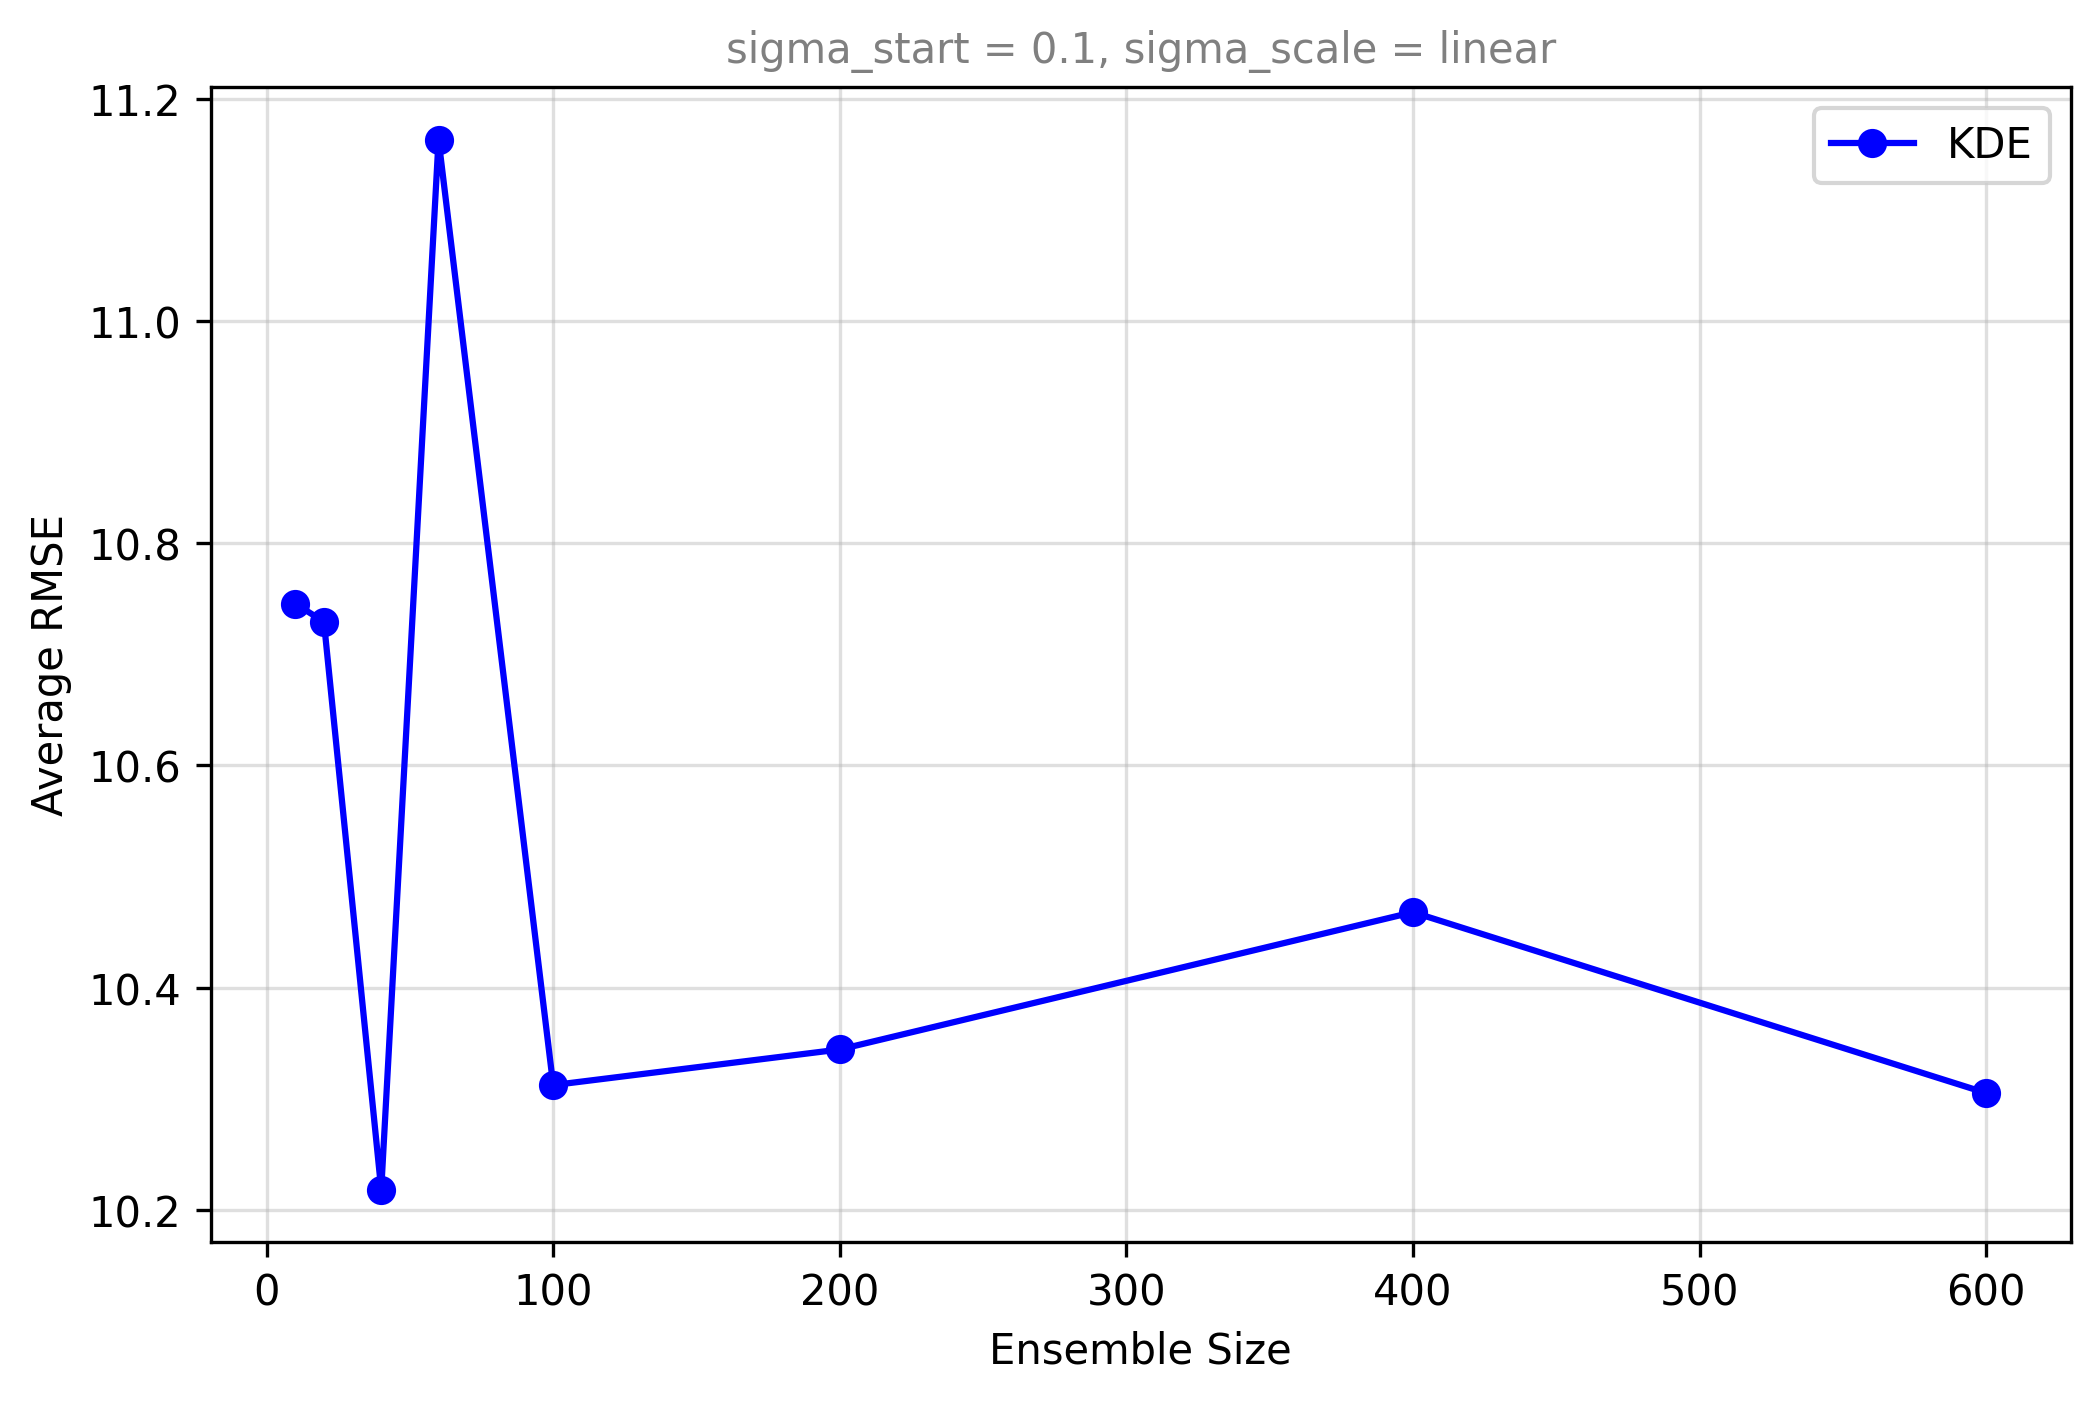

Button(button_style='success', description='Save Plot', style=ButtonStyle())

In [19]:
plot_rmses(models, filter)

In [20]:
plot_lorenz63(models, filter)
#TODO: plot different values of sigma_start, use their generated data

interactive(children=(FloatSlider(value=200.0, description='Start Time', max=595.0000000000001, min=200.0, ste…